# Ablation 01 — Dictionary-Size / Expansion-Ratio Ladder (lr pinned)

The baseline (dict_size=4096, 8x expansion) shows ~44% dead features and near-total cross-seed Jaccard collapse (mean ≈ 0.0038, null expectation ≈ 0.0039). Is over-expansion the shared cause?

**lr pinned to 4e-4 across all sizes** so capacity is the only moving variable. (At these sizes lr=auto already equals 4e-4 — all below the 16384 reference — but pinning removes any ambiguity.)

**Pre-registered hypothesis:** smaller `dict_size` → dead% drops AND signal-to-null Jaccard ratio rises (raw Jaccard is corrected by the hypergeometric null, which itself grows as dict_size shrinks).

**Hard protocol rules:**

1. **WITHIN-GROUP JACCARD.** `compute_stability` intersects top-k feature-INDEX sets, only meaningful at constant dict_size/k. Compute Jaccard **only within each dict_size group**. Cross-size comparison uses the signal-to-null ratio and consensus-reappearance rate (index-agnostic).
2. **OUTPUT-DIR ISOLATION.** Override `models_dir`/`results_dir`/`figures_dir` to ablation-isolated subdirs; per-dict-size leaf in the training loop keeps `sae_seed{N}` collision-free.
3. **NO VOCAB REBUILD.** Use committed `data/vocabulary.json` + `embeddings/text_vocab_embeddings.pt`.
4. **SAFE DESERIALIZATION.** All `torch.load` via `utils.load_tensor`/`utils.load_state_dict` (`weights_only=True`).
5. **TEST-SET DISCIPLINE.** Stability/Jaccard/naming use test embeddings only.
6. **REPRODUCIBILITY.** Threads + `PYTHONHASHSEED` pinned before torch import. Seeds `(0, 42, 123)`; `primary_seed=42`.

Also included: an `lr=None` sensitivity arm (§8) and a revival probe on dict2048 (§7, designed negative finding).

## 0. Setup & Configuration

In [1]:
import os
# Pin BEFORE importing torch.
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

import sys
import json
import math
from pathlib import Path

import torch

# Resolve project root by walking up until 'src/' exists.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}')
print(f"Device available: {'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'}")

Project root: /home/marcantoniolopez/Documenti/github/xai-project-5
PyTorch: 2.12.0+cu130
Device available: cuda


In [2]:
import config
import utils

# OUTPUT-DIR ISOLATION (Protocol rule 2): PathsConfig is mutable, override in place.
ABLATION_TAG = 'ablation_a1'   # dir name encodes the ablation; collides with nothing

config.paths.models_dir = PROJECT_ROOT / 'models' / ABLATION_TAG
config.paths.results_dir = PROJECT_ROOT / 'results' / 'ablation'

# Unified figures dir across all ablation notebooks (EXACT path).
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'ablation'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
config.paths.figures_dir = FIGURES_DIR

for d in (config.paths.models_dir, config.paths.results_dir, config.paths.figures_dir):
    d.mkdir(parents=True, exist_ok=True)

print('=== Ablation 01 — isolated paths ===')
print(f'Models:   {config.paths.models_dir}')
print(f'Results:  {config.paths.results_dir}')
print(f'Figures:  {config.paths.figures_dir}')

DEVICE = config.hardware.device
print(f'\nDevice (from config): {DEVICE}')

/home/marcantoniolopez/Documenti/github/xai-project-5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Ablation 01 — isolated paths ===
Models:   /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1
Results:  /home/marcantoniolopez/Documenti/github/xai-project-5/results/ablation
Figures:  /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/ablation

Device (from config): cuda


In [3]:
# Ablation parameters (see title cell for rationale).
ABLATION_SEEDS = (0, 42, 123)          # Protocol rule 6: 3 seeds for ablation training
PRIMARY_SEED = 42                       # reference model for naming

DICT_SIZES = (1024, 2048, 4096)         # expansion ratio over the 512-d embedding
K = 32                                   # top-k activation — FIXED across all groups
LR_PINNED = 4e-4                         # PRIMARY ARM: lr pinned, capacity is the only variable
N_STEPS = 12_000                         # shortened from the 50k baseline; sufficient for convergence
BATCH_SIZE = config.sae.batch_size       # 256
WARMUP_STEPS = config.sae.warmup_steps   # 1000
ACTIVATION_DIM = config.sae.activation_dim   # 512

print('=== Ablation 01 parameters ===')
print(f'  {"dict_sizes":<20} {DICT_SIZES}')
print(f'  {"k (top-k)":<20} {K}')
print(f'  {"lr (PINNED)":<20} {LR_PINNED}')
print(f'  {"steps":<20} {N_STEPS}')
print(f'  {"batch_size":<20} {BATCH_SIZE}')
print(f'  {"warmup_steps":<20} {WARMUP_STEPS}')
print(f'  {"activation_dim":<20} {ACTIVATION_DIM}')
print(f'  {"seeds":<20} {ABLATION_SEEDS}')
print(f'  {"primary_seed":<20} {PRIMARY_SEED}')
print()
print('NOTE: auxk_alpha is left at the TopKTrainer library default (1/32).')
print('SAEManager.train does not forward auxk_alpha in its trainer_config,')
print('so the default applies silently (documented, not configurable via SAEManager).')

=== Ablation 01 parameters ===
  dict_sizes           (1024, 2048, 4096)
  k (top-k)            32
  lr (PINNED)          0.0004
  steps                12000
  batch_size           256
  warmup_steps         1000
  activation_dim       512
  seeds                (0, 42, 123)
  primary_seed         42

NOTE: auxk_alpha is left at the TopKTrainer library default (1/32).
SAEManager.train does not forward auxk_alpha in its trainer_config,
so the default applies silently (documented, not configurable via SAEManager).


In [4]:
# Verify inputs exist (Protocol rule 5: test embeddings drive stability).
data_files = [
    ('train_embeddings.pt', config.paths.train_embeddings_path),
    ('test_embeddings.pt', config.paths.test_embeddings_path),
    ('text_vocab_embeddings.pt', config.paths.vocab_embeddings_path),
    ('vocabulary.json', config.paths.vocab_labels_path),
]

print('=== Data Verification ===')
all_ok = True
for name, path in data_files:
    exists = path.exists()
    print(f'  [{"OK" if exists else "MISSING"}] {name} -> {path}')
    if not exists:
        all_ok = False

assert all_ok, 'Missing inputs — run embedding extraction + split first.'

# Safe deserialization via utils.load_tensor (weights_only=True).
train_emb = utils.load_tensor(config.paths.train_embeddings_path)
test_emb = utils.load_tensor(config.paths.test_embeddings_path)
vocab_emb = utils.load_tensor(config.paths.vocab_embeddings_path)
with open(config.paths.vocab_labels_path) as f:
    # vocabulary.json entries may be dicts or strings; normalize to term strings.
    vocab_labels = [
        e['term'] if isinstance(e, dict) else e for e in json.load(f)
    ]

print(f'\nTrain embeddings: {train_emb.shape}  (used for training)')
print(f'Test embeddings:  {test_emb.shape}  (used for metrics + Jaccard + naming)')
print(f'Vocab embeddings: {vocab_emb.shape}  ({len(vocab_labels)} terms)')

=== Data Verification ===
  [OK] train_embeddings.pt -> /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/augmented/train_embeddings.pt
  [OK] test_embeddings.pt -> /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/augmented/test_embeddings.pt
  [OK] text_vocab_embeddings.pt -> /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/augmented/text_vocab_embeddings.pt
  [OK] vocabulary.json -> /home/marcantoniolopez/Documenti/github/xai-project-5/data/vocabulary.json

Train embeddings: torch.Size([17865, 512])  (used for training)
Test embeddings:  torch.Size([4545, 512])  (used for metrics + Jaccard + naming)
Vocab embeddings: torch.Size([508, 512])  (508 terms)


## 1. Training Ladder — dict_size ∈ {1024, 2048, 4096} × seeds (0,42,123), lr pinned

Mirrors the baseline loop parameterized over `dict_size`. Each (dict_size, seed) trains a TopK SAE via `SAEManager`, which writes `save_dir/dict{D}/sae_seed{N}/trainer_0/ae.pt`. The 4096 point is a fresh 12k-step run, not the 50k baseline checkpoint.

In [5]:
from autoencoder.sae_module import SAEManager

# models_a1 / dict{D} / sae_seed{N} / trainer_0 / ae.pt
models_a1 = config.paths.models_dir

trained = {}   # trained[D][seed] = Path(model_dir)
for D in DICT_SIZES:
    trained[D] = {}
    size_dir = models_a1 / f'dict{D}'
    size_dir.mkdir(parents=True, exist_ok=True)
    for seed in ABLATION_SEEDS:
        target = size_dir / f'sae_seed{seed}'
        # Idempotent: skip if already trained.
        if (target / 'training_manifest.json').exists():
            print(f'[skip] dict{D} seed{seed} already trained -> {target}')
            trained[D][seed] = target
            continue

        print(f'\n--- Training dict_size={D} seed={seed} (lr={LR_PINNED}, steps={N_STEPS}) ---')
        mgr = SAEManager({
            'device': DEVICE,
            'activation_dim': ACTIVATION_DIM,
            'dict_size': D,
            'k': K,
            'lr': LR_PINNED,           # PRIMARY ARM: lr pinned across all sizes
            'warmup_steps': WARMUP_STEPS,
        })
        model_dir = mgr.train(
            embeddings_path=config.paths.train_embeddings_path,
            seed=seed,
            save_dir=size_dir,
            steps=N_STEPS,
            batch_size=BATCH_SIZE,
        )
        trained[D][seed] = Path(model_dir)
        print(f'Saved: {model_dir}')

print('\n=== Training ladder complete ===')
for D in DICT_SIZES:
    print(f'  dict{D}: {[str(trained[D][s].name) for s in ABLATION_SEEDS]}')

20:32:01 | INFO | Loaded 17865 embeddings from /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/augmented/train_embeddings.pt


20:32:01 | INFO | drop_last=True: 201 trailing samples skipped per epoch (step-based training cycles many epochs, so all data is seen).


20:32:01 | INFO | Training SAE (seed=0, steps=12000, lr=4.0e-04, decay_start=9600)...



--- Training dict_size=1024 seed=0 (lr=0.0004, steps=12000) ---


  0%|          | 0/12000 [00:00<?, ?it/s]

...

100%|█████████▉| 11994/12000 [00:42<00:00, 298.14it/s]

100%|██████████| 12000/12000 [00:42<00:00, 285.11it/s]


20:37:59 | INFO | Model saved to /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed123


20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed123

=== Training ladder complete ===
  dict1024: ['sae_seed0', 'sae_seed42', 'sae_seed123']
  dict2048: ['sae_seed0', 'sae_seed42', 'sae_seed123']
  dict4096: ['sae_seed0', 'sae_seed42', 'sae_seed123']


## 2. Per-size within-group metrics (reconstruction, dead%, L0)

Load each size's 3 models and compute per-seed reconstruction MSE / cosine and sparsity (dead%, L0) on the TEST set. The causal story comes from the signal-to-null ratio in §4.

In [6]:
per_size_metrics = {}   # per_size_metrics[D][seed] = {...}

for D in DICT_SIZES:
    per_size_metrics[D] = {}
    print(f'\n=== dict_size={D} (within-group) ===')
    for seed in ABLATION_SEEDS:
        mgr = SAEManager({
            'device': DEVICE,
            'activation_dim': ACTIVATION_DIM,
            'dict_size': D,
            'k': K,
        })
        mgr.load(trained[D][seed])

        mse = mgr.compute_reconstruction_mse(test_emb)
        cos = mgr.compute_cosine_reconstruction(test_emb)
        sp = mgr.compute_sparsity_metrics(test_emb)

        per_size_metrics[D][seed] = {
            'mse': mse,
            'cosine': cos,
            'l0_mean': sp['l0_mean'],
            'dead_features_pct': sp['dead_features_pct'],
            'dict_utilization_pct': sp['dict_utilization_pct'],
            'activation_entropy': sp['activation_entropy'],
        }
        print(f'  seed={seed}: cosine={cos:.4f}  mse={mse:.2e}  '
              f'dead%={sp["dead_features_pct"]:.1f}  L0={sp["l0_mean"]:.1f}  '
              f'util={sp["dict_utilization_pct"]:.1f}%')
        del mgr

# Group means (over seeds)
print('\n=== Group means (over 3 seeds) ===')
for D in DICT_SIZES:
    vals = list(per_size_metrics[D].values())
    n = len(vals)
    mean_cos = sum(m['cosine'] for m in vals) / n
    mean_dead = sum(m['dead_features_pct'] for m in vals) / n
    mean_mse = sum(m['mse'] for m in vals) / n
    print(f'  dict{D}: cosine={mean_cos:.4f}  dead%={mean_dead:.1f}  mse={mean_mse:.2e}')

20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict2048/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict2048/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


...

20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)



=== dict_size=1024 (within-group) ===
  seed=0: cosine=0.9950  mse=1.97e-05  dead%=47.5  L0=32.0  util=52.5%
  seed=42: cosine=0.9950  mse=1.94e-05  dead%=48.4  L0=32.0  util=51.6%
  seed=123: cosine=0.9949  mse=2.01e-05  dead%=39.7  L0=32.0  util=60.3%

=== dict_size=2048 (within-group) ===
  seed=0: cosine=0.9947  mse=2.06e-05  dead%=50.6  L0=32.0  util=49.4%
  seed=42: cosine=0.9948  mse=2.03e-05  dead%=54.1  L0=32.0  util=45.9%
  seed=123: cosine=0.9948  mse=2.03e-05  dead%=50.7  L0=32.0  util=49.3%

=== dict_size=4096 (within-group) ===


20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


  seed=0: cosine=0.9944  mse=2.19e-05  dead%=60.8  L0=32.0  util=39.2%
  seed=42: cosine=0.9944  mse=2.18e-05  dead%=61.5  L0=32.0  util=38.5%
  seed=123: cosine=0.9943  mse=2.24e-05  dead%=58.6  L0=32.0  util=41.4%

=== Group means (over 3 seeds) ===
  dict1024: cosine=0.9950  dead%=45.2  mse=1.97e-05
  dict2048: cosine=0.9948  dead%=51.8  mse=2.04e-05
  dict4096: cosine=0.9944  dead%=60.3  mse=2.20e-05


## 3. Per-size within-group Jaccard (Protocol rule 1)

`compute_stability` intersects per-sample top-k feature-INDEX sets — only meaningful at constant `dict_size`/`k`. Called once per dict_size with that size's 3 model dirs and a config fixing `dict_size`/`k` (`n` defaults to `k=32`). **Never compute Jaccard across dict sizes** — use the signal-to-null ratio (§4) and consensus reappearance (§5) instead.

In [7]:
per_size_jaccard = {}   # per_size_jaccard[D] = stability dict

for D in DICT_SIZES:
    model_dirs = [trained[D][seed] for seed in ABLATION_SEEDS]
    print(f'\n=== dict_size={D} within-group Jaccard (3 seeds) ===')
    stab = SAEManager.compute_stability(
        model_dirs,
        test_emb,
        config={
            'device': DEVICE,
            'activation_dim': ACTIVATION_DIM,
            'dict_size': D,     # CRITICAL: matches the loaded models
            'k': K,             # CRITICAL: constant across groups -> n defaults to 32
        },
    )
    per_size_jaccard[D] = stab
    print(f'  mean_jaccard = {stab["mean_jaccard"]:.6f}  std = {stab["std_jaccard"]:.6f}')
    print(f'  matrix:\n{stab["jaccard_matrix"]}')

20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:37:59 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)



=== dict_size=1024 within-group Jaccard (3 seeds) ===


20:38:00 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict2048/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


...

  mean_jaccard = 0.014916  std = 0.001988
  matrix:
tensor([[1.0000, 0.0176, 0.0128],
        [0.0176, 1.0000, 0.0144],
        [0.0128, 0.0144, 1.0000]])

=== dict_size=2048 within-group Jaccard (3 seeds) ===


20:38:00 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


20:38:00 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


20:38:00 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


  mean_jaccard = 0.006929  std = 0.002148
  matrix:
tensor([[1.0000, 0.0053, 0.0100],
        [0.0053, 1.0000, 0.0055],
        [0.0100, 0.0055, 1.0000]])

=== dict_size=4096 within-group Jaccard (3 seeds) ===
  mean_jaccard = 0.004465  std = 0.001695
  matrix:
tensor([[1.0000, 0.0035, 0.0068],
        [0.0035, 1.0000, 0.0031],
        [0.0068, 0.0031, 1.0000]])


## 4. Signal-to-null ratio (cross-size causal claim)

Raw Jaccard grows trivially as dict_size shrinks (smaller universe → more overlap by chance). To isolate the signal we divide each group's mean Jaccard by the hypergeometric null: `E[J] = E[|A∩B|]/E[|A∪B|]` with `E[|A∩B|] = k²/D`, `E[|A∪B|] = 2k − k²/D` (≈ `k/(2D−k)` for `k << D`; they agree to 4 decimals here).

**Pre-registered claim:** the ratio rises as dict_size shrinks — smaller dictionaries are genuinely more robust seed-to-seed, not just trivially denser.

In [8]:
def null_jaccard(k, D):
    """Hypergeometric null E[J] for two independent size-k subsets of a D-set."""
    e_inter = (k * k) / D
    e_union = 2 * k - e_inter
    return e_inter / e_union

def null_jaccard_approx(k, D):
    """k/(2D-k) — exact at k<<D."""
    return k / (2 * D - k)

signal_null = {}
print('=== Signal-to-null Jaccard ratio (per dict_size) ===')
print(f'{"dict_size":>10} {"raw_J":>10} {"null_exact":>12} {"null_approx":>12} {"ratio":>10}')
for D in DICT_SIZES:
    raw = per_size_jaccard[D]['mean_jaccard']
    null_e = null_jaccard(K, D)
    null_a = null_jaccard_approx(K, D)
    ratio = raw / null_e
    signal_null[D] = {'raw_jaccard': raw, 'null_exact': null_e, 'null_approx': null_a, 'ratio': ratio}
    print(f'{D:>10} {raw:>10.6f} {null_e:>12.6f} {null_a:>12.6f} {ratio:>10.4f}')

print('\n(At baseline dict=4096 the ratio hovers near 1.0 = no signal above chance.)')
print('(Pre-registered: smaller dict_size -> ratio RISES.)')

=== Signal-to-null Jaccard ratio (per dict_size) ===
 dict_size      raw_J   null_exact  null_approx      ratio
      1024   0.014916     0.015873     0.015873     0.9397
      2048   0.006929     0.007874     0.007874     0.8800
      4096   0.004465     0.003922     0.003922     1.1387

(At baseline dict=4096 the ratio hovers near 1.0 = no signal above chance.)
(Pre-registered: smaller dict_size -> ratio RISES.)


## 5. Consensus reappearance rate (index-agnostic cross-seed robustness)

An index-agnostic signal: pool the **live** decoder rows from a size's 3 seeds, cluster by cosine similarity at `tau=0.90`, and count clusters spanning ≥ 2 seeds. A robust dictionary rediscovers the same directions across seeds; an over-expanded one produces idiosyncratic directions.

Uses `scipy.sparse.csgraph.connected_components` on a `cosine > tau` adjacency over pooled live rows (dead rows dropped, norm < 1e-8) — the same algorithm as a0/a1/a4 for comparability. a0's near-null result is expected here and reported as such.

In [9]:
import numpy as np
import torch.nn.functional as F
from scipy import sparse
from scipy.sparse.csgraph import connected_components

CONSENSUS_TAU = 0.90   # cosine boundary, STRICT (> tau); matches ablation 00

def pooled_live_decoder_rows(D, seed_to_dir, dead_threshold=1e-8):
    """Return (rows[N,512], seed_labels[N]) for all LIVE decoder rows across
    this size's seeds (dead rows dropped before pooling, matching ablation 00)."""
    rows_list, seed_labels = [], []
    for seed in ABLATION_SEEDS:
        mgr = SAEManager({'device': DEVICE, 'activation_dim': ACTIVATION_DIM,
                          'dict_size': D, 'k': K})
        mgr.load(seed_to_dir[seed])
        W = mgr.get_decoder_weights().cpu()        # (D, 512)
        norms = W.norm(dim=1)
        live = (norms >= dead_threshold).nonzero(as_tuple=True)[0]
        rows_list.append(W[live].clone())
        seed_labels.append(torch.full((len(live),), seed, dtype=torch.long))
        del mgr
    rows = torch.cat(rows_list, dim=0).float()
    labels = torch.cat(seed_labels, dim=0).numpy()
    return rows, labels

def consensus_reappearance(D, seed_to_dir, tau=CONSENSUS_TAU):
    """Connected-components consensus on pooled LIVE decoder rows (matches a0):
    build a sparse `cosine > tau` adjacency over L2-normalized rows, run
    connected_components, count clusters spanning >= 2 of 3 seeds."""
    rows, labels = pooled_live_decoder_rows(D, seed_to_dir)
    rows_n = F.normalize(rows, dim=1).numpy().astype(np.float64)
    # cosine = W @ W.T (rows unit-norm); exclude self-edges
    cos_full = rows_n @ rows_n.T
    np.fill_diagonal(cos_full, -1.0)
    # sparse `cosine > tau` graph (STRICT > tau, matches ablation 00)
    adj = sparse.csr_matrix(cos_full > tau)
    n_clusters, cluster_labels = connected_components(csgraph=adj, directed=False)
    spans_multi = 0
    row_seedcount = np.empty(len(labels), dtype=np.int64)
    for c in range(n_clusters):
        member_seeds = np.unique(labels[cluster_labels == c])
        if len(member_seeds) >= 2:   # >= 2 of 3 seeds
            spans_multi += 1
        row_seedcount[cluster_labels == c] = len(member_seeds)
    reappearance_rate = spans_multi / n_clusters if n_clusters else 0.0
    return {
        'n_pooled_rows': int(len(rows)),
        'n_clusters': int(n_clusters),
        'n_clusters_multi_seed': int(spans_multi),
        'reappearance_rate': float(reappearance_rate),
        'tau': float(tau),
    }

consensus = {}
print('=== Consensus reappearance (connected_components, cosine > 0.90, matches a0) ===')
print(f'{"dict_size":>10} {"pooled":>8} {"clusters":>9} {"multi-seed":>11} {"rate":>8}')
for D in DICT_SIZES:
    c = consensus_reappearance(D, trained[D])
    consensus[D] = c
    print(f'{D:>10} {c["n_pooled_rows"]:>8} {c["n_clusters"]:>9} '
          f'{c["n_clusters_multi_seed"]:>11} {c["reappearance_rate"]:>8.3f}')
print('\n(Higher reappearance_rate = more directions rediscovered across seeds. '
      'Matches a0: expect ~null at tau=0.90.)')

20:38:00 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:38:00 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:38:00 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


=== Consensus reappearance (connected_components, cosine > 0.90, matches a0) ===
 dict_size   pooled  clusters  multi-seed     rate


      1024     3072      3068           2    0.001


...

20:38:01 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


20:38:01 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


20:38:01 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


      2048     6144      6140           2    0.000


      4096    12288     12284           2    0.000

(Higher reappearance_rate = more directions rediscovered across seeds. Matches a0: expect ~null at tau=0.90.)


## 6. Feature-splitting index (mean pairwise cosine among alive decoder rows)

Over-expansion is hypothesized to cause **feature splitting**: many atoms collapse onto a few redundant directions, raising mean pairwise cosine among alive decoder rows. Estimated on a random subsample of 2000 alive rows pooled across the 3 seeds (subsample keeps the pairwise `O(n²)` comparison tractable).

In [10]:
SPLIT_SUBSAMPLE = 2000
splitting = {}

print('=== Feature-splitting index (mean pairwise cosine, alive rows) ===')
for D in DICT_SIZES:
    rows, _ = pooled_live_decoder_rows(D, trained[D])
    if len(rows) > SPLIT_SUBSAMPLE:
        idx = torch.randperm(len(rows))[:SPLIT_SUBSAMPLE]
        rows = rows[idx]
    rows_n = F.normalize(rows, dim=1)
    sim = rows_n @ rows_n.T                      # (n, n) cosine
    n = sim.shape[0]
    # exclude diagonal; mean of strict upper triangle
    iu = torch.triu_indices(n, n, offset=1)
    mean_cos = sim[iu[0], iu[1]].mean().item()
    p90 = sim[iu[0], iu[1]].quantile(0.9).item()
    splitting[D] = {'mean_pairwise_cosine': mean_cos, 'p90_pairwise_cosine': p90,
                    'n_rows_sampled': int(n)}
    print(f'  dict{D}: mean_cos={mean_cos:.4f}  p90_cos={p90:.4f}  (n={n})')
print('\n(Higher mean cosine => more redundant / split directions.)')

20:38:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:38:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:38:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


=== Feature-splitting index (mean pairwise cosine, alive rows) ===


20:38:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict2048/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


...

20:38:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


20:38:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


20:38:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


  dict2048: mean_cos=0.0057  p90_cos=0.0858  (n=2000)


  dict4096: mean_cos=0.0039  p90_cos=0.0785  (n=2000)

(Higher mean cosine => more redundant / split directions.)


## 7. Revival probe — dict2048, lowered dead threshold + stronger auxk (designed negative finding)

Hypothesis: reviving dead features (lower `dead_feature_threshold` + stronger `auxk_alpha=1/8`) drops **dead%** but leaves **within-group Jaccard flat** — alive-but-arbitrary features are decoupled from robustness.

We bypass `SAEManager.train` (hardcodes `TopKTrainer`, omits `auxk_alpha`/`dead_feature_threshold`) and call `trainSAE` directly. Since `TopKTrainer` hardcodes `self.dead_feature_threshold = 10_000_000` in `__init__` and does **not** accept it as a kwarg, a thin subclass (`RevivalTopKTrainer`) assigns it after `super().__init__()`. `auxk_alpha` passes through unchanged.

In [11]:
from dictionary_learning.trainers.top_k import AutoEncoderTopK, TopKTrainer
from dictionary_learning.training import trainSAE

# Thin subclass: TopKTrainer hardcodes dead_feature_threshold in __init__ and
# won't accept it as a kwarg, so assign it after super().__init__().
class RevivalTopKTrainer(TopKTrainer):
    def __init__(self, dead_feature_threshold=10_000_000, **kw):
        super().__init__(**kw)
        self.dead_feature_threshold = dead_feature_threshold

REVIVAL_D = 2048
REVIVAL_STEPS = N_STEPS
REVIVAL_LR = LR_PINNED
REVIVAL_DEAD_THRESHOLD = 256_000     # tokens — well below the 10_000_000 default
REVIVAL_AUXK_ALPHA = 1.0 / 8.0       # stronger aux loss (default is 1/32)

revival_dir = config.paths.models_dir / 'revival_probe'
revival_dir.mkdir(parents=True, exist_ok=True)

def batch_gen():
    while True:
        perm = torch.randperm(len(train_emb))
        for i in range(0, len(perm), BATCH_SIZE):
            yield train_emb[perm[i:i + BATCH_SIZE]].to(DEVICE)

trained_revival = {}
for seed in ABLATION_SEEDS:
    seed_dir = revival_dir / f'sae_seed{seed}'
    if (seed_dir / 'trainer_0' / 'ae.pt').exists() or (seed_dir / 'ae.pt').exists():
        print(f'[skip] revival seed{seed} already trained')
        trained_revival[seed] = seed_dir
        continue
    print(f'\n--- Revival probe: dict{REVIVAL_D} seed={seed} '
          f'(dead_thresh={REVIVAL_DEAD_THRESHOLD}, auxk={REVIVAL_AUXK_ALPHA:.3f}) ---')
    trainer_cfg = {
        'trainer': RevivalTopKTrainer,
        'activation_dim': ACTIVATION_DIM,
        'dict_size': REVIVAL_D,
        'k': K,
        'steps': REVIVAL_STEPS,
        'layer': 0,
        'lm_name': 'biomedclip',
        'lr': REVIVAL_LR,
        'warmup_steps': WARMUP_STEPS,
        'decay_start': int(REVIVAL_STEPS * config.sae.decay_start_frac),
        'auxk_alpha': REVIVAL_AUXK_ALPHA,
        'dead_feature_threshold': REVIVAL_DEAD_THRESHOLD,
        'seed': seed,
        'device': DEVICE,
    }
    trainSAE(
        data=batch_gen(),
        trainer_configs=[trainer_cfg],
        steps=REVIVAL_STEPS,
        save_dir=str(seed_dir),
        log_steps=config.sae.log_steps,
        normalize_activations=False,
        verbose=True,
        device=DEVICE,
        autocast_dtype=torch.float32 if DEVICE in ('cpu', 'mps') else torch.bfloat16,
    )
    trained_revival[seed] = seed_dir
    print(f'Saved: {seed_dir}')

print('\n=== Revival probe training complete ===')


--- Revival probe: dict2048 seed=0 (dead_thresh=256000, auxk=0.125) ---


  0%|          | 0/12000 [00:00<?, ?it/s]

  0%|          | 55/12000 [00:00<00:22, 542.53it/s]

Step 0: L0 = 32.0, frac_variance_explained = -0.3673989772796631


  1%|          | 110/12000 [00:00<00:33, 354.41it/s]

...

 99%|█████████▉| 11910/12000 [00:40<00:00, 241.83it/s]

 99%|█████████▉| 11936/12000 [00:40<00:00, 240.59it/s]

100%|█████████▉| 11985/12000 [00:40<00:00, 304.36it/s]

100%|██████████| 12000/12000 [00:40<00:00, 292.97it/s]

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/revival_probe/sae_seed123

=== Revival probe training complete ===


In [12]:
# Revival probe metrics: dead% (should drop) + within-group Jaccard (expected flat).
revival_metrics = {}
print('=== Revival probe: per-seed dead% / L0 / cosine ===')
for seed in ABLATION_SEEDS:
    mgr = SAEManager({'device': DEVICE, 'activation_dim': ACTIVATION_DIM,
                      'dict_size': REVIVAL_D, 'k': K})
    mgr.load(trained_revival[seed])
    sp = mgr.compute_sparsity_metrics(test_emb)
    cos = mgr.compute_cosine_reconstruction(test_emb)
    revival_metrics[seed] = {'dead_features_pct': sp['dead_features_pct'],
                             'l0_mean': sp['l0_mean'], 'cosine': cos}
    print(f'  seed={seed}: dead%={sp["dead_features_pct"]:.1f}  L0={sp["l0_mean"]:.1f}  '
          f'cosine={cos:.4f}')
    del mgr

# Within-group Jaccard for the revival group.
revival_dirs = [trained_revival[seed] for seed in ABLATION_SEEDS]
revival_stab = SAEManager.compute_stability(
    revival_dirs, test_emb,
    config={'device': DEVICE, 'activation_dim': ACTIVATION_DIM,
            'dict_size': REVIVAL_D, 'k': K},
)
print(f'\nRevival within-group mean Jaccard = {revival_stab["mean_jaccard"]:.6f}')

revival_null = null_jaccard(K, REVIVAL_D)
print(f'Revival raw_J={revival_stab["mean_jaccard"]:.6f}  null={revival_null:.6f}  '
      f'ratio={revival_stab["mean_jaccard"] / revival_null:.4f}')

ref = per_size_jaccard[REVIVAL_D]['mean_jaccard']
print(f'\nComparison (dict{REVIVAL_D}):')
print(f'  standard (auxk=1/32, dead=10M): dead%={sum(m["dead_features_pct"] for m in per_size_metrics[REVIVAL_D].values())/3:.1f}  '
      f'Jaccard={ref:.6f}')
print(f'  revival  (auxk=1/8,  dead=256k): dead%={sum(m["dead_features_pct"] for m in revival_metrics.values())/3:.1f}  '
      f'Jaccard={revival_stab["mean_jaccard"]:.6f}')
print('\nEXPECTED (designed negative finding): dead% DROPS, Jaccard roughly FLAT')
print('=> revival makes features alive-but-arbitrary, decoupled from robustness.')

20:40:12 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/revival_probe/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


20:40:12 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/revival_probe/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


20:40:12 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/revival_probe/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


20:40:12 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/revival_probe/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


20:40:12 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/revival_probe/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


20:40:12 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/revival_probe/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


=== Revival probe: per-seed dead% / L0 / cosine ===
  seed=0: dead%=39.6  L0=32.0  cosine=0.9947
  seed=42: dead%=37.9  L0=32.0  cosine=0.9947
  seed=123: dead%=38.7  L0=32.0  cosine=0.9947

Revival within-group mean Jaccard = 0.007028
Revival raw_J=0.007028  null=0.007874  ratio=0.8925

Comparison (dict2048):
  standard (auxk=1/32, dead=10M): dead%=51.8  Jaccard=0.006929
  revival  (auxk=1/8,  dead=256k): dead%=38.7  Jaccard=0.007028

EXPECTED (designed negative finding): dead% DROPS, Jaccard roughly FLAT
=> revival makes features alive-but-arbitrary, decoupled from robustness.


## 8. Sensitivity appendix — lr=None (auto) per dict_size

Audits the lr-pinning decision: at these sizes `TopKTrainer` auto-scale (`2e-4 / sqrt(dict_size/16384)`) equals 4e-4 for all three (all below the 16384 reference). Confirms the primary arm's effect is genuinely capacity, not lr.

In [13]:
auto_models_a1 = config.paths.models_dir.parent / (ABLATION_TAG + '_auto')
auto_models_a1.mkdir(parents=True, exist_ok=True)

trained_auto = {}
for D in DICT_SIZES:
    trained_auto[D] = {}
    size_dir = auto_models_a1 / f'dict{D}'
    size_dir.mkdir(parents=True, exist_ok=True)
    for seed in ABLATION_SEEDS:
        target = size_dir / f'sae_seed{seed}'
        if (target / 'training_manifest.json').exists():
            print(f'[skip] auto dict{D} seed{seed} -> {target}')
            trained_auto[D][seed] = target
            continue
        print(f'\n--- Sensitivity: dict_size={D} seed={seed} (lr=None/auto, steps={N_STEPS}) ---')
        mgr = SAEManager({
            'device': DEVICE,
            'activation_dim': ACTIVATION_DIM,
            'dict_size': D,
            'k': K,
            'lr': None,                # AUTO arm
            'warmup_steps': WARMUP_STEPS,
        })
        model_dir = mgr.train(
            embeddings_path=config.paths.train_embeddings_path,
            seed=seed,
            save_dir=size_dir,
            steps=N_STEPS,
            batch_size=BATCH_SIZE,
        )
        trained_auto[D][seed] = Path(model_dir)
        print(f'Saved: {model_dir}')

print('\n=== Sensitivity (lr=auto) ladder complete ===')


--- Sensitivity: dict_size=1024 seed=0 (lr=None/auto, steps=12000) ---


20:40:12 | INFO | Loaded 17865 embeddings from /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/augmented/train_embeddings.pt


20:40:12 | INFO | drop_last=True: 201 trailing samples skipped per epoch (step-based training cycles many epochs, so all data is seen).


20:40:12 | INFO | Training SAE (seed=0, steps=12000, lr=auto, decay_start=9600)...


  0%|          | 0/12000 [00:00<?, ?it/s]

...

100%|█████████▉| 11964/12000 [00:42<00:00, 302.39it/s]

100%|██████████| 12000/12000 [00:42<00:00, 281.26it/s]


20:46:03 | INFO | Model saved to /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto/dict4096/sae_seed123


20:46:03 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto/dict4096/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto/dict4096/sae_seed123

=== Sensitivity (lr=auto) ladder complete ===


In [14]:
# Sensitivity: dead% and within-group Jaccard per size at lr=auto.
auto_summary = {}
print('=== Sensitivity (lr=auto) summary ===')
print(f'{"dict_size":>10} {"mean_dead%":>11} {"mean_cosine":>12} {"mean_J":>10} {"null":>10} {"ratio":>8}')
for D in DICT_SIZES:
    dead_vals, cos_vals = [], []
    for seed in ABLATION_SEEDS:
        mgr = SAEManager({'device': DEVICE, 'activation_dim': ACTIVATION_DIM,
                          'dict_size': D, 'k': K})
        mgr.load(trained_auto[D][seed])
        sp = mgr.compute_sparsity_metrics(test_emb)
        cos = mgr.compute_cosine_reconstruction(test_emb)
        dead_vals.append(sp['dead_features_pct'])
        cos_vals.append(cos)
        del mgr
    stab = SAEManager.compute_stability(
        [trained_auto[D][seed] for seed in ABLATION_SEEDS], test_emb,
        config={'device': DEVICE, 'activation_dim': ACTIVATION_DIM, 'dict_size': D, 'k': K},
    )
    null_e = null_jaccard(K, D)
    auto_summary[D] = {
        'mean_dead_pct': float(np.mean(dead_vals)),
        'mean_cosine': float(np.mean(cos_vals)),
        'mean_jaccard': stab['mean_jaccard'],
        'ratio': stab['mean_jaccard'] / null_e,
    }
    print(f'{D:>10} {np.mean(dead_vals):>11.1f} {np.mean(cos_vals):>12.4f} '
          f'{stab["mean_jaccard"]:>10.6f} {null_e:>10.6f} {stab["mean_jaccard"]/null_e:>8.4f}')
print('\n(At these dict sizes lr=auto == lr=4e-4 pinned, so the two arms should match.)')

20:46:03 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto/dict1024/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:46:03 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto/dict1024/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:46:03 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto/dict1024/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:46:03 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto/dict1024/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:46:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto/dict1024/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


...

20:46:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto/dict4096/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


      2048        61.9       0.9950   0.007427   0.007874   0.9433


20:46:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto/dict4096/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


20:46:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto/dict4096/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


      4096        60.3       0.9944   0.004465   0.003922   1.1387

(At these dict sizes lr=auto == lr=4e-4 pinned, so the two arms should match.)


## 9. Concept naming (primary seed 42) per dict_size

Name each size's primary-seed features against the committed vocabulary (RadLex, 508 terms) using **gap-corrected** cosine (`W_dec -= (visual_centroid - text_centroid)` before normalize+cosine), mirroring the baseline. The gap is computed inline from canonical train/vocab embeddings.

In [15]:
# Modality gap (Solution 1): visual_centroid - text_centroid, applied to W_dec.
# Computed inline from the canonical train/vocab embeddings (= models/modality_gap.pt).
modality_gap = train_emb.mean(dim=0) - vocab_emb.mean(dim=0)

naming_summary = {}
print('=== Concept naming (primary seed 42, gap-corrected) per dict_size ===')
for D in DICT_SIZES:
    mgr = SAEManager({'device': DEVICE, 'activation_dim': ACTIVATION_DIM,
                      'dict_size': D, 'k': K})
    mgr.load(trained[D][PRIMARY_SEED])
    names = mgr.name_concepts(
        vocab_emb,
        vocab_labels,
        top_n=config.explanation.concept_top_n,
        modality_gap=modality_gap,
    )
    live_scores = [v['score'] for v in names.values() if not v['is_dead']]
    mean_s = float(np.mean(live_scores)) if live_scores else 0.0
    max_s = float(np.max(live_scores)) if live_scores else 0.0
    n_dead = sum(1 for v in names.values() if v['is_dead'])
    naming_summary[D] = {
        'mean_decoder_vocab_cosine': mean_s,
        'max_decoder_vocab_cosine': max_s,
        'n_dead_naming': n_dead,
        'n_total': len(names),
    }
    print(f'  dict{D}: mean_cos={mean_s:.4f}  max_cos={max_s:.4f}  '
          f'dead(naming)={n_dead}/{len(names)}')
    out = config.paths.results_dir / f'a1_naming_dict{D}.json'
    with open(out, 'w') as f:
        json.dump(names, f, indent=2, ensure_ascii=False)
    del mgr
print(f'\n(Baseline dict=4096 seed42 (gap-corrected): mean ~0.395, max ~0.546.)')

20:46:04 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:46:05 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict2048/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


=== Concept naming (primary seed 42, gap-corrected) per dict_size ===
  dict1024: mean_cos=0.3884  max_cos=0.5479  dead(naming)=0/1024


20:46:05 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


  dict2048: mean_cos=0.3871  max_cos=0.5353  dead(naming)=0/2048


  dict4096: mean_cos=0.3845  max_cos=0.5289  dead(naming)=0/4096

(Baseline dict=4096 seed42 (gap-corrected): mean ~0.395, max ~0.546.)


## 10. Figures

1. **Stability-vs-capacity frontier** — x=reconstruction cosine, y=signal-to-null Jaccard ratio, one point per dict_size, dead% on a secondary axis.
2. **Feature-splitting dendrogram** per size (scipy `hierarchy` on pooled alive decoder subsample).
3. **Dead% vs dict_size** and **raw-Jaccard vs dict_size** twin-axis.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
FIGS = FIGURES_DIR   # unified ablation figures dir (PROJECT_ROOT/results/figures/ablation)
FIGS.mkdir(parents=True, exist_ok=True)
print(f'Figures dir: {FIGS}')

dicts = list(DICT_SIZES)
mean_cos = [np.mean([per_size_metrics[D][s]['cosine'] for s in ABLATION_SEEDS]) for D in dicts]
ratios = [signal_null[D]['ratio'] for D in dicts]
dead = [np.mean([per_size_metrics[D][s]['dead_features_pct'] for s in ABLATION_SEEDS]) for D in dicts]

Figures dir: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/ablation


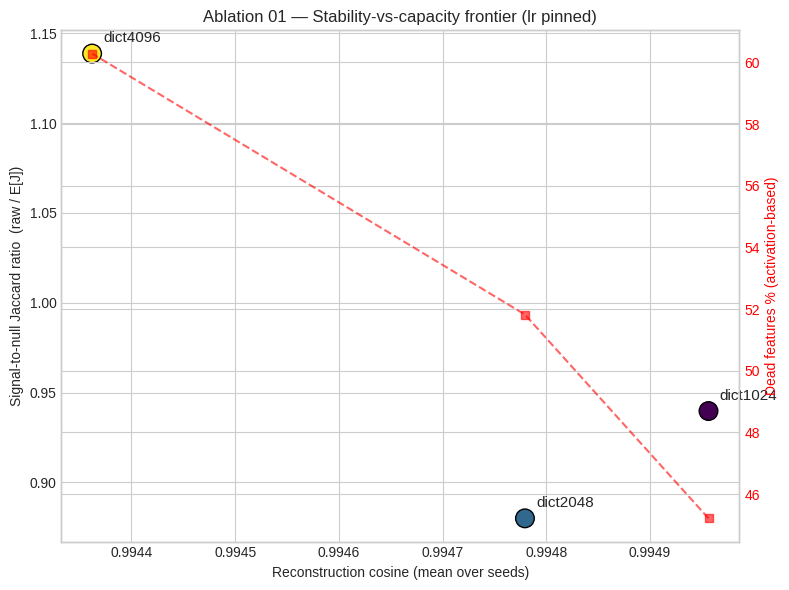

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/ablation/a1_stability_frontier.png


In [17]:
# (1) Stability-vs-capacity frontier: cosine (x) vs signal-to-null ratio (y), dead% on twin axis.
fig, ax1 = plt.subplots(figsize=(8, 6))
sc = ax1.scatter(mean_cos, ratios, c=dicts, cmap='viridis', s=180, edgecolor='k', zorder=3)
for x, y, D in zip(mean_cos, ratios, dicts):
    ax1.annotate(f'dict{D}', (x, y), textcoords='offset points', xytext=(8, 8), fontsize=11)
ax1.set_xlabel('Reconstruction cosine (mean over seeds)')
ax1.set_ylabel('Signal-to-null Jaccard ratio  (raw / E[J])')
ax1.set_title('Ablation 01 — Stability-vs-capacity frontier (lr pinned)')
ax2 = ax1.twinx()
ax2.plot(mean_cos, dead, 'r--s', alpha=0.6, label='dead%')
ax2.set_ylabel('Dead features % (activation-based)', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.tight_layout()
plt.savefig(FIGS / 'a1_stability_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGS / "a1_stability_frontier.png"}')

20:46:06 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:46:06 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:46:06 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict1024/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=1024, k=32)


20:46:07 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict2048/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


20:46:07 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict2048/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


20:46:07 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict2048/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=2048, k=32)


20:46:07 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


20:46:07 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


20:46:07 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/dict4096/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


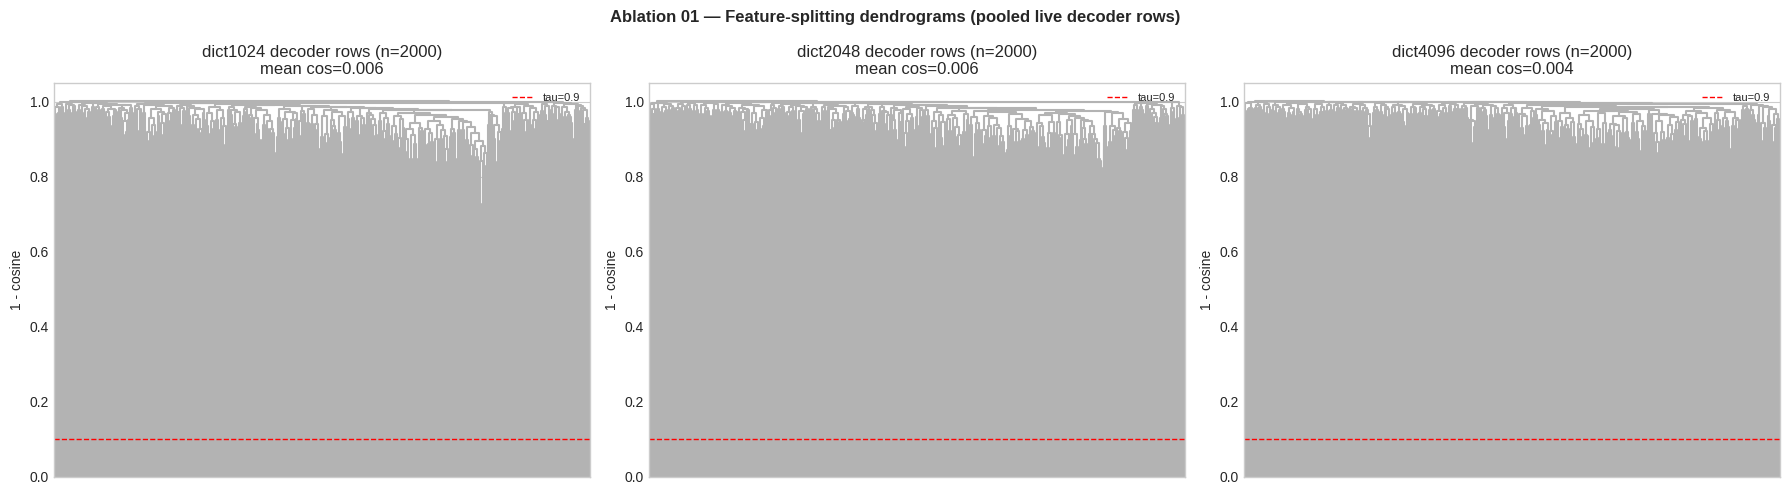

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/ablation/a1_splitting_dendrogram.png


In [18]:
# (2) Feature-splitting dendrogram per size (pooled alive decoder subsample).
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

fig, axes = plt.subplots(1, len(dicts), figsize=(6 * len(dicts), 5))
for ax, D in zip(axes, dicts):
    rows, _ = pooled_live_decoder_rows(D, trained[D])
    if len(rows) > SPLIT_SUBSAMPLE:
        rows = rows[torch.randperm(len(rows))[:SPLIT_SUBSAMPLE]]
    rows_n = F.normalize(rows, dim=1).numpy()
    cond = pdist(rows_n, metric='cosine')
    Z = linkage(cond, method='average')
    dendrogram(Z, no_labels=True, color_threshold=1 - CONSENSUS_TAU, ax=ax,
               above_threshold_color='0.7')
    ax.set_title(f'dict{D} decoder rows (n={len(rows)})\nmean cos={splitting[D]["mean_pairwise_cosine"]:.3f}')
    ax.set_ylabel('1 - cosine')
    ax.axhline(1 - CONSENSUS_TAU, color='r', ls='--', lw=1, label=f'tau={CONSENSUS_TAU}')
    ax.legend(fontsize=8)
fig.suptitle('Ablation 01 — Feature-splitting dendrograms (pooled live decoder rows)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'a1_splitting_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGS / "a1_splitting_dendrogram.png"}')

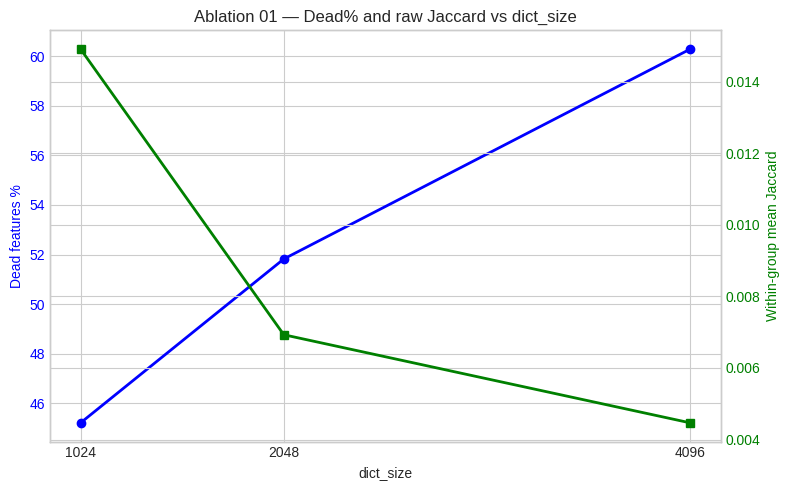

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/ablation/a1_dead_jaccard_vs_dict.png


In [19]:
# (3) Dead% vs dict_size + raw Jaccard vs dict_size (twin axis).
fig, ax1 = plt.subplots(figsize=(8, 5))
raw_J = [per_size_jaccard[D]['mean_jaccard'] for D in dicts]
ax1.plot(dicts, dead, 'b-o', label='dead%', lw=2)
ax1.set_xlabel('dict_size')
ax1.set_ylabel('Dead features %', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(dicts, raw_J, 'g-s', label='raw Jaccard', lw=2)
ax2.set_ylabel('Within-group mean Jaccard', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax1.set_title('Ablation 01 — Dead% and raw Jaccard vs dict_size')
ax1.set_xticks(dicts)
fig.tight_layout()
plt.savefig(FIGS / 'a1_dead_jaccard_vs_dict.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGS / "a1_dead_jaccard_vs_dict.png"}')

## 11. Summary — write `results/ablation/a1_dict_size.json`

Persist per-size metrics, null ratios, consensus reappearance, splitting index, the revival probe, the sensitivity (lr=auto) appendix, and naming summaries.

In [20]:
summary = {
    'ablation': '01_dict_size',
    'params': {
        'dict_sizes': list(DICT_SIZES),
        'k': K,
        'lr_primary': LR_PINNED,
        'lr_sensitivity': 'None (auto)',
        'steps': N_STEPS,
        'batch_size': BATCH_SIZE,
        'warmup_steps': WARMUP_STEPS,
        'activation_dim': ACTIVATION_DIM,
        'seeds': list(ABLATION_SEEDS),
        'primary_seed': PRIMARY_SEED,
        'trainer': 'TopKTrainer (hardcoded in SAEManager.train)',
        'auxk_alpha': 'library default 1/32 (SAEManager.train does not forward it)',
        'naming': 'gap-corrected (Solution 1: W_dec -= visual_centroid - text_centroid)',
    },
    'baseline_reference': {
        'reconstruction_cosine': 0.988,
        'variance_explained': 0.993,
        'dead_pct_activation': 44.0,
        'mean_index_jaccard': 0.0038,
        'naming_mean_cos': 0.3949,
        'naming_max_cos': 0.5457,
    },
    'per_size': {},
}

for D in DICT_SIZES:
    summary['per_size'][str(D)] = {
        'metrics_by_seed': {str(s): per_size_metrics[D][s] for s in ABLATION_SEEDS},
        'mean_cosine': float(np.mean([per_size_metrics[D][s]['cosine'] for s in ABLATION_SEEDS])),
        'mean_dead_pct': float(np.mean([per_size_metrics[D][s]['dead_features_pct'] for s in ABLATION_SEEDS])),
        'within_group_jaccard': {
            'mean': per_size_jaccard[D]['mean_jaccard'],
            'std': per_size_jaccard[D]['std_jaccard'],
            'matrix': per_size_jaccard[D]['jaccard_matrix'].tolist(),
        },
        'signal_to_null': signal_null[D],
        'consensus_reappearance': consensus[D],
        'feature_splitting': splitting[D],
        'naming_primary_seed': naming_summary[D],
    }

summary['revival_probe'] = {
    'dict_size': REVIVAL_D,
    'dead_feature_threshold': REVIVAL_DEAD_THRESHOLD,
    'auxk_alpha': REVIVAL_AUXK_ALPHA,
    'steps': REVIVAL_STEPS,
    'lr': REVIVAL_LR,
    'metrics_by_seed': {str(s): revival_metrics[s] for s in ABLATION_SEEDS},
    'mean_dead_pct': float(np.mean([revival_metrics[s]['dead_features_pct'] for s in ABLATION_SEEDS])),
    'within_group_jaccard': {
        'mean': revival_stab['mean_jaccard'],
        'std': revival_stab['std_jaccard'],
    },
    'signal_to_null_ratio': revival_stab['mean_jaccard'] / revival_null,
    'expected_finding': 'dead% down, Jaccard flat (alive-but-arbitrary, decoupled from robustness)',
}

summary['sensitivity_lr_auto'] = {
    str(D): auto_summary[D] for D in DICT_SIZES
}

summary['hypothesis'] = {
    'pre_registered': 'smaller dict_size -> dead% drops AND signal-to-null ratio rises',
    'lr_pinning_rationale': 'pinning lr=4e-4 makes capacity the only moving variable; '
                            'at these sizes lr=auto coincides with 4e-4 (all < 16384 ref), '
                            'confirmed by the sensitivity appendix',
}

out_path = config.paths.results_dir / 'a1_dict_size.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f'Saved: {out_path}  ({out_path.stat().st_size / 1024:.1f} KB)')
print('\n=== Per-size recap ===')
for D in DICT_SIZES:
    s = summary['per_size'][str(D)]
    print(f'  dict{D}: cosine={s["mean_cosine"]:.4f}  dead%={s["mean_dead_pct"]:.1f}  '
          f'raw_J={s["within_group_jaccard"]["mean"]:.6f}  '
          f'null={s["signal_to_null"]["null_exact"]:.6f}  '
          f'ratio={s["signal_to_null"]["ratio"]:.3f}  '
          f'reapp={s["consensus_reappearance"]["reappearance_rate"]:.3f}')

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/ablation/a1_dict_size.json  (9.0 KB)

=== Per-size recap ===
  dict1024: cosine=0.9950  dead%=45.2  raw_J=0.014916  null=0.015873  ratio=0.940  reapp=0.001
  dict2048: cosine=0.9948  dead%=51.8  raw_J=0.006929  null=0.007874  ratio=0.880  reapp=0.000
  dict4096: cosine=0.9944  dead%=60.3  raw_J=0.004465  null=0.003922  ratio=1.139  reapp=0.000


In [21]:
print('=' * 60)
print('  ABLATION 01 COMPLETE')
print('=' * 60)
print(f'Primary models:  {config.paths.models_dir}')
print(f'Auto (sens.):    {auto_models_a1}')
print(f'Revival probe:   {revival_dir}')
print(f'Results JSON:    {out_path}')
print(f'Naming JSONs:    {config.paths.results_dir}/a1_naming_dict*.json')
print(f'Figures:         {FIGS}')
for fig in sorted(FIGS.glob('a1_*.png')):
    print(f'  - {fig.name}  ({fig.stat().st_size / 1024:.1f} KB)')

  ABLATION 01 COMPLETE
Primary models:  /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1
Auto (sens.):    /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1_auto
Revival probe:   /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a1/revival_probe
Results JSON:    /home/marcantoniolopez/Documenti/github/xai-project-5/results/ablation/a1_dict_size.json
Naming JSONs:    /home/marcantoniolopez/Documenti/github/xai-project-5/results/ablation/a1_naming_dict*.json
Figures:         /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/ablation
  - a1_dead_jaccard_vs_dict.png  (71.9 KB)
  - a1_splitting_dendrogram.png  (64.6 KB)
  - a1_stability_frontier.png  (73.2 KB)
